### Business Problem:
the bank wants to first understand customer spending behavior <br>and then use that behavioral insight to predict loan acceptance likelihood. <br> 

leverage customer demographic and financial data to:<br>
1. Predict a customer’s expected monthly credit card spending<br>
2. Use that predicted behavior with other key variables to identify customers most likely to accept a personal loan offer.


In [1]:
### Importing the necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
# read and show initial data insights:
df = pd.read_excel(r"Loan_Modelling.xlsx")
df.head()


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [3]:
# Key-insights:
df.shape

(5000, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [5]:
df.describe()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [6]:
# CLeaning:

df.duplicated().sum()

np.int64(0)

In [15]:
# Data insights:
# to start my study with studying the history of the customers who accepted the personal loan and study them

df["Personal_Loan"].value_counts()




Personal_Loan
0    4520
1     480
Name: count, dtype: int64

In [38]:
num_cols= df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove("Personal_Loan")
num_cols.remove("ID")
num_cols

['Age',
 'Experience',
 'Income',
 'ZIPCode',
 'Family',
 'CCAvg',
 'Education',
 'Mortgage',
 'Securities_Account',
 'CD_Account',
 'Online',
 'CreditCard']

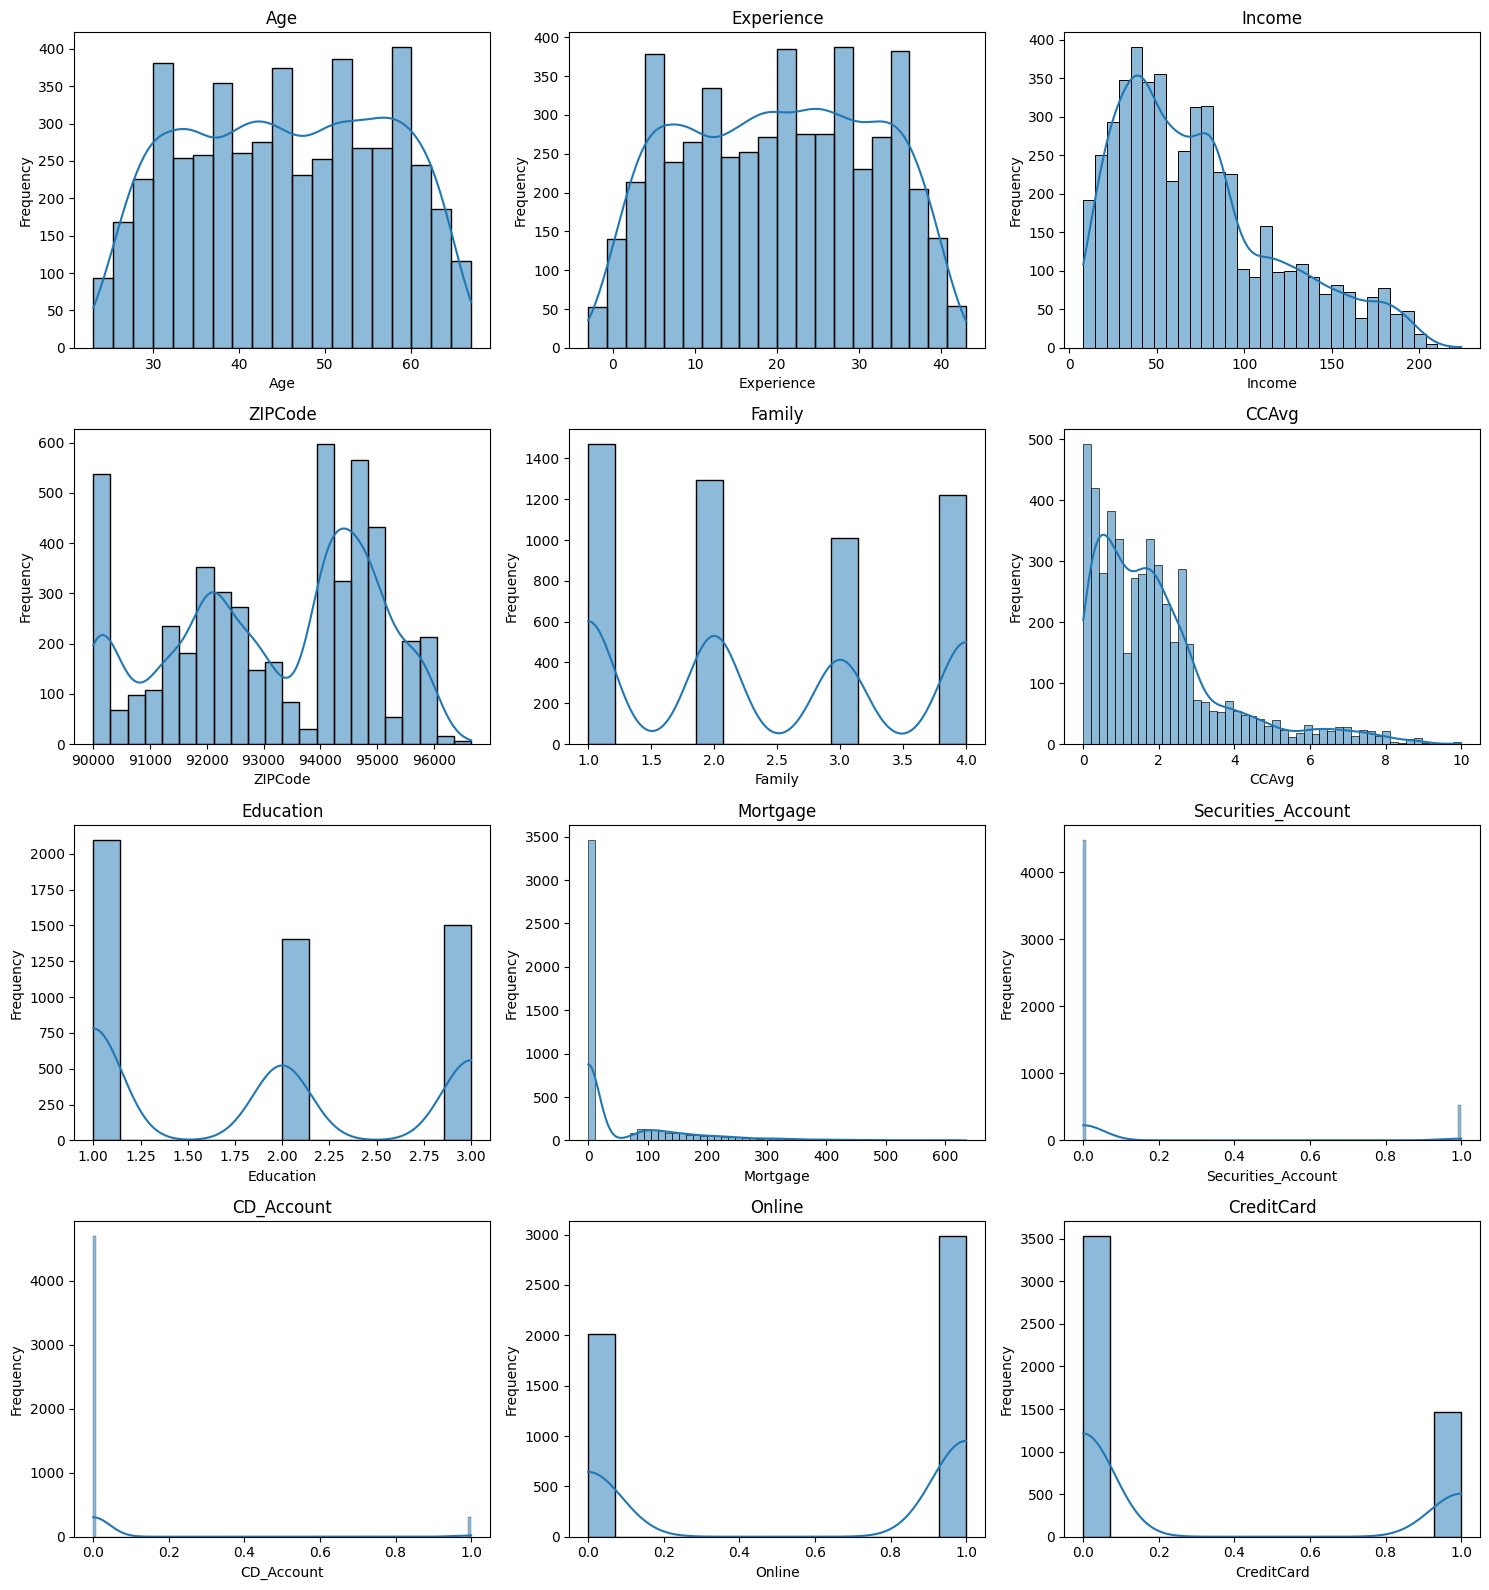

In [39]:
n_cols = 3                     # histograms per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

_______
________
### Income vs Personal Loan

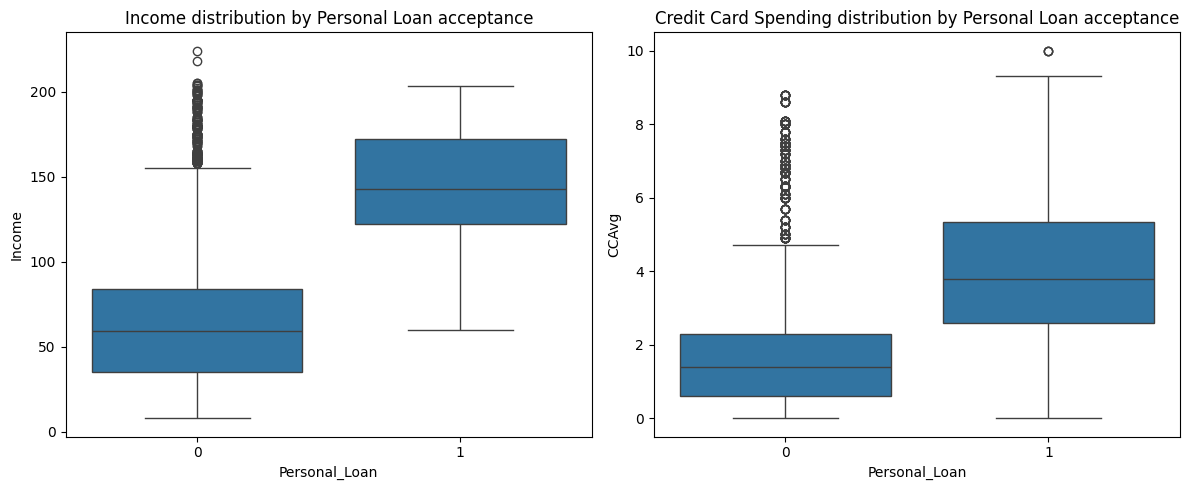

In [26]:
#boxplot to see the distribution of income and credit card spending for those who accepted the loan and those who did not:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x="Personal_Loan", y="Income", data=df)
plt.title("Income distribution by Personal Loan acceptance")
plt.subplot(1,2,2)
sns.boxplot(x="Personal_Loan", y="CCAvg", data=df)
plt.title("Credit Card Spending distribution by Personal Loan acceptance")
plt.tight_layout()
plt.show()

#### THis means that higher income customers are more likely to get a personal loan, and that customers with higher credit card spending are also more likely to get a personal loan. This insight can help the bank target their marketing efforts towards customers who are more likely to accept a personal loan offer.
___________________

### Income vs Credit Card Spending

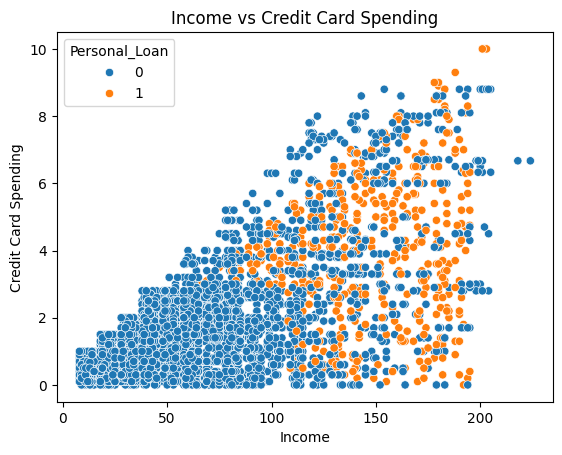

In [17]:
# plot income and credit card spending to see the relationship between them:
sns.scatterplot(x="Income", y="CCAvg", hue="Personal_Loan", data=df)
plt.title("Income vs Credit Card Spending")
plt.xlabel("Income")
plt.ylabel("Credit Card Spending")
plt.show()

This means higher income higher credit carsd spending 

____________

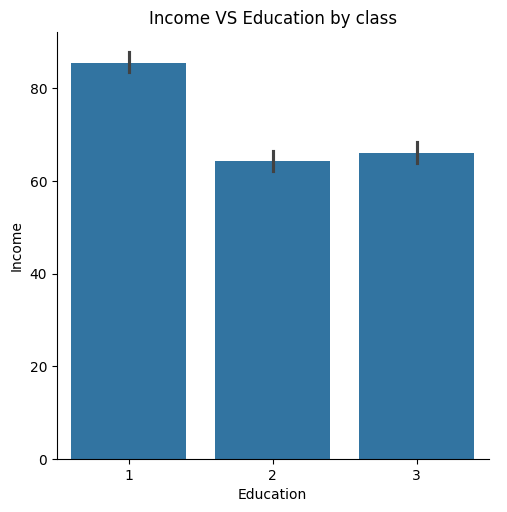

In [44]:
#experiance and income plot:
sns.catplot(x="Education", y="Income", kind ="bar", data = df)
plt.title("Income VS Education by class")
plt.show()


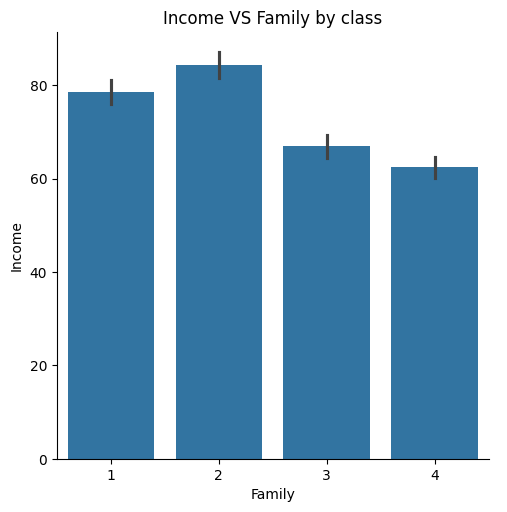

In [53]:
#experiance and income plot:
sns.catplot(x="Family", y="Income", kind ="bar", data = df)
plt.title("Income VS Family by class")
plt.show()

________

_________